### Libraries and Functions

In [38]:
import pandas as pd
import numpy as np
import pickle

from tqdm import tqdm
from sympy import Basic
from joblib import Parallel, delayed
from matplotlib.patches import Patch

from symbolic_regression.utils.visualization import plot_results
from symbolic_regression.utils.io_utils import load_pickle_files
from symbolic_regression.utils.model_utils import tree_size

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [39]:
def get_final_expr(
    dataset_equations: dict[str, list],
    method: str,
    run_idx: int
) -> Basic:
    """
    Extracts the final SymPy expression for a given method and run.

    For the 'RFGPCMI' method, it returns the sum of the final sub-expressions. 
    For all other methods, it returns the single final expression.

    Parameters
    ----------
    dataset_equations : dict[str, list]
        A dictionary containing the equations for a dataset, keyed by method name.
    method : str
        The name of the symbolic regression method (e.g., 'GP', 'RFGPCMI').
    run_idx : int
        The index of the execution run to extract the expression from.

    Returns
    -------
    Basic
        The final SymPy expression.
    """

    if method != "RFGPCMI":
        return dataset_equations [method][run_idx][-1].sympy_format
    
    else:
        return sum(
            sub_expr[-1].sympy_format 
            for sub_expr in dataset_equations [method][run_idx]
        ) # type: ignore

def remove_suffix_recursively(
    data: str | list | dict | tuple | set,
    suffix: str
) -> str | list | dict | tuple | set:
    """
    Recursive function that traverses lists, dictionaries, tuples, and sets
    to clean the contained strings.

    Parameters
    ----------
    data : str | list | dict | tuple | set
        The data structure to clean.
    suffix : str
        The suffix to remove from strings. For example, if the suffix is "_f2",
        then "X_f2" would become "X".

    Returns
    -------
    str | list | dict | tuple | set
        The cleaned data structure with the suffix removed from all strings.
    """

    if isinstance(data, str):
        return data.removesuffix(suffix)
    elif isinstance(data, list):
        return [remove_suffix_recursively(item, suffix) for item in data]
    elif isinstance(data, tuple):
        return tuple(remove_suffix_recursively(item, suffix) for item in data)
    elif isinstance(data, set):
        return {remove_suffix_recursively(item, suffix) for item in data} # type: ignore
    elif isinstance(data, dict):
        return {key: remove_suffix_recursively(val, suffix) for key, val in data.items()}
    else:
        return data  # Return as is if it's not a supported iterable/iterable type

### Data Preprocessing

In [40]:
# Load real dataset results
with open("data_real.pkl", "rb") as f:
    real = pickle.load(f)['kwargs']

results_df, features, equations = real['df'], real['features'], real['equations']

# Calculate the number dataframe index runs level
num_runs = results_df.index.get_level_values('run').nunique()

# Reorder MultiIndex columns for consistent plotting
order = {
    'dataset': ['197_cpu_act', '4544_GOM', '505_tecator', 'CCN', 'CCUN'],
    'method':  ['GPPI', 'GPSHAP', 'GPCMI', 'RFGPCMI', 'GP'],
    'metric':  ['training_losses', 'validation_losses', 'test_losses']
}

for level, cols in order.items():
    results_df = results_df.reindex(columns=cols, level=level)

# Remove dataset suffixes from feature names for cleaner display
for ds in features:
    features[ds] = remove_suffix_recursively(features[ds], f"_{ds.lower()}")
    features[ds] = remove_suffix_recursively(features[ds], f"_{ds.upper()}")

results_df.tail(3)

dataset       197_cpu_act                                                \
method               GPPI                                        GPSHAP   
metric    training_losses validation_losses test_losses training_losses   
run epoch                                                                 
99  80           0.084818          0.086722    0.084164        0.110206   
    90           0.085206          0.085766    0.084164        0.111092   
    100          0.084936          0.086429    0.084151        0.110450   

dataset                                                                    \
method                                            GPCMI                     
metric    validation_losses test_losses training_losses validation_losses   
run epoch                                                                   
99  80             0.112669    0.108552        0.110724          0.111410   
    90             0.110472    0.108552        0.111514          0.109424   
    100            0.112070    0.108552        0.110813          0.111189   

dataset                                ...        CCUN                  \
method                        RFGPCMI  ...      GPSHAP           GPCMI   
metric    test_losses training_losses  ... test_losses training_losses   
run epoch                              ...                               
99  80       0.108549        0.061343  ...    0.160684        0.134422   
    90       0.108549        0.046507  ...    0.160684        0.144646   
    100      0.108549        0.046524  ...    0.156960        0.141759   

dataset                                                                    \
method                                          RFGPCMI                     
metric    validation_losses test_losses training_losses validation_losses   
run epoch                                                                   
99  80             0.200472    0.160539        0.129802          0.167409   
    90             0.145502    0.160539        0.129529          0.164151   
    100            0.150018    0.160539        0.129529          0.164151   

dataset                                                              
method                             GP                                
metric    test_losses training_losses validation_losses test_losses  
run epoch                                                            
99  80       0.150995        0.155020          0.114012    0.157318  
    90       0.147566        0.143781          0.171012    0.163481  
    100      0.147566        0.135983          0.163666    0.159521  

[3 rows x 75 columns]

In [ ]:
# Load execution times for each run, method, and dataset
execution_times = {}
for dataset_name in order['dataset']:
    execution_times[dataset_name] = {}
    
    for method_name in order['method']:
        folder = f"data/real_params/{dataset_name}/{method_name}/"
        loaded = load_pickle_files(folder)

        execution_times[dataset_name][method_name] = np.array(
            [run_data['metadata']['execution_duration_seconds'] for run_data in loaded]
        )

### Predictive Performance

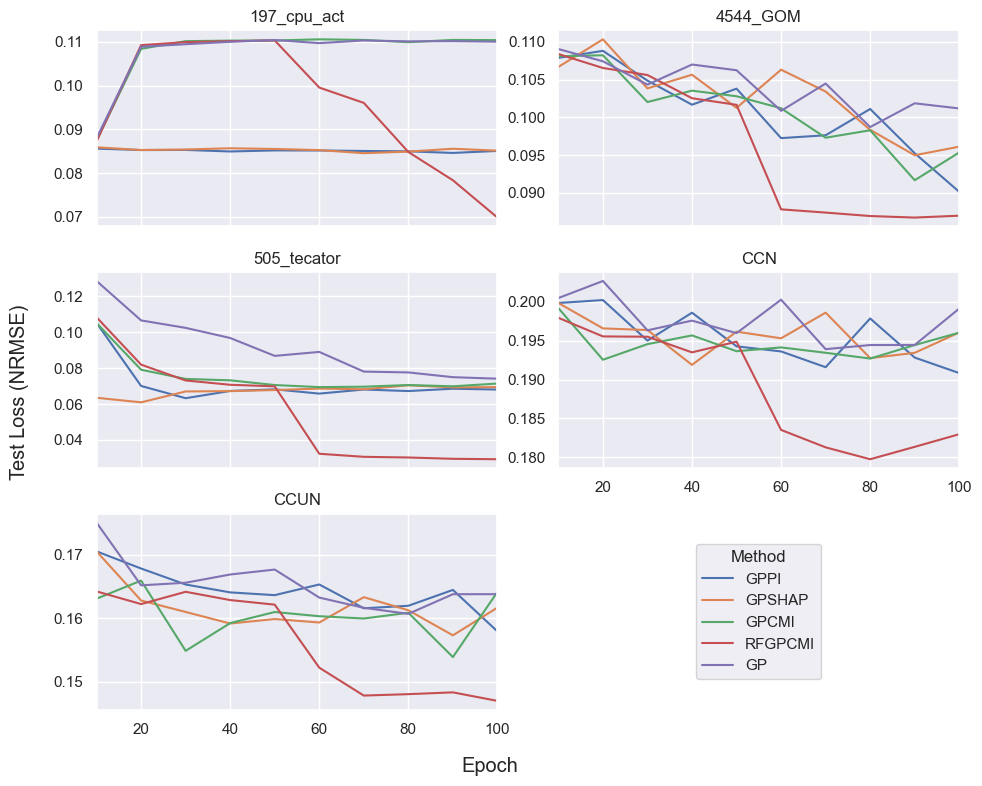

In [17]:
# Plotting test losses for each dataset and method per epoch
fig, axes = plot_results(
    results_df.groupby(level='epoch').median(), 
    nrows=3, 
    ncols=2,
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric",
    value_key="validation_losses",
    plotting_function=lambda data, ax: sns.lineplot(data=data, ax=ax, dashes=None)
)

# Set X and Y label for the entire figure
fig.supxlabel("Epoch", x=0.5, y=0.02)
fig.supylabel("Test Loss (NRMSE)", x=0.02, y=0.5)

axes[0].set_xlim(10, 100) # Set x-axis limits to show all epochs
axes[4].set_xlabel("") # Hide the x-label

# Remove legends from individual subplots
for ax in axes[:5]: ax.get_legend().remove()

# Take the legend handles and labels from the first subplot
handles, labels = axes[0].get_legend_handles_labels()

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center',
    title="Method"
)

plt.show()

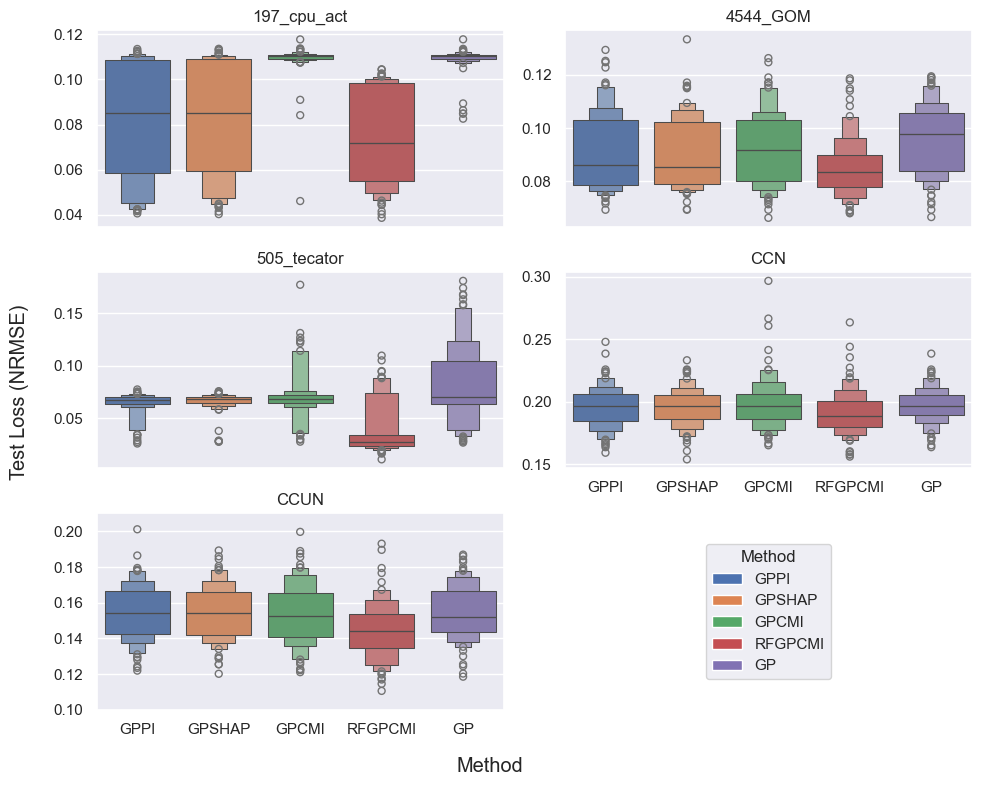

In [28]:
# Plotting test losses for each dataset and method at the last epoch
fig, axes = plot_results(
    results_df.groupby(level='run').last(), 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric", 
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.boxenplot(data=data, ax=ax)
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Test Loss (NRMSE)", x=0.02, y=0.5)

axes[4].set_ylim(0.1, 0.21) # Set y-axis limits to zoom in on the boxenplots

# Create a custom legend with the same colors as the boxenplots
colors = sns.color_palette(n_colors=len(order['method']))
handles = [Patch(facecolor=c) for c in colors]
labels = order['method'].copy()

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)

plt.show()

In [33]:
# Calculate median test losses for each method and dataset at the last epoch
median_loss = results_df.groupby(level='run').last().median()
gp_median_loss = median_loss[:, "GP", :]

# Extract the list of methods excluding "GP" for comparison
methods = results_df.columns.levels[1].to_list()
methods.remove("GP")

# Extract the median losses for the competitor methods
competitor_median_loss = median_loss.loc[:, methods, :]

# Calculate relative improvement of GP over competitors for each dataset and metric
relative_improvement = (gp_median_loss - competitor_median_loss) * 100 / gp_median_loss
relative_improvement_df = relative_improvement.to_frame().T

# Reorder the relative improvement DataFrame to match the desired column order for plotting
relative_improvement_df = relative_improvement_df.swaplevel('metric', 'method', axis=1)
relative_improvement_df = relative_improvement_df.reindex(columns=order['dataset'], level='dataset')
relative_improvement_df = relative_improvement_df.reindex(columns=methods, level='method')
relative_improvement_df = relative_improvement_df.reindex(columns=order['metric'], level='metric')
relative_improvement_df

dataset     197_cpu_act                                                \
method             GPPI                                        GPSHAP   
metric  training_losses validation_losses test_losses training_losses   
0             23.063409         22.659483   22.957601       22.831969   

dataset                                                                  \
method                                          GPCMI                     
metric  validation_losses test_losses training_losses validation_losses   
0               22.612023   22.721363         -0.0815         -0.324127   

dataset                              ...        CCUN                  \
method                      RFGPCMI  ...        GPPI          GPSHAP   
metric  test_losses training_losses  ... test_losses training_losses   
0          0.018134       35.653979  ...   -1.454374       -0.025435   

dataset                                                                  \
method                                          GPCMI                     
metric  validation_losses test_losses training_losses validation_losses   
0                1.294545   -1.342462        1.317114         -0.220593   

dataset                                                            
method                      RFGPCMI                                
metric  test_losses training_losses validation_losses test_losses  
0         -0.272885        8.008703         10.269098    5.406874  

[1 rows x 60 columns]

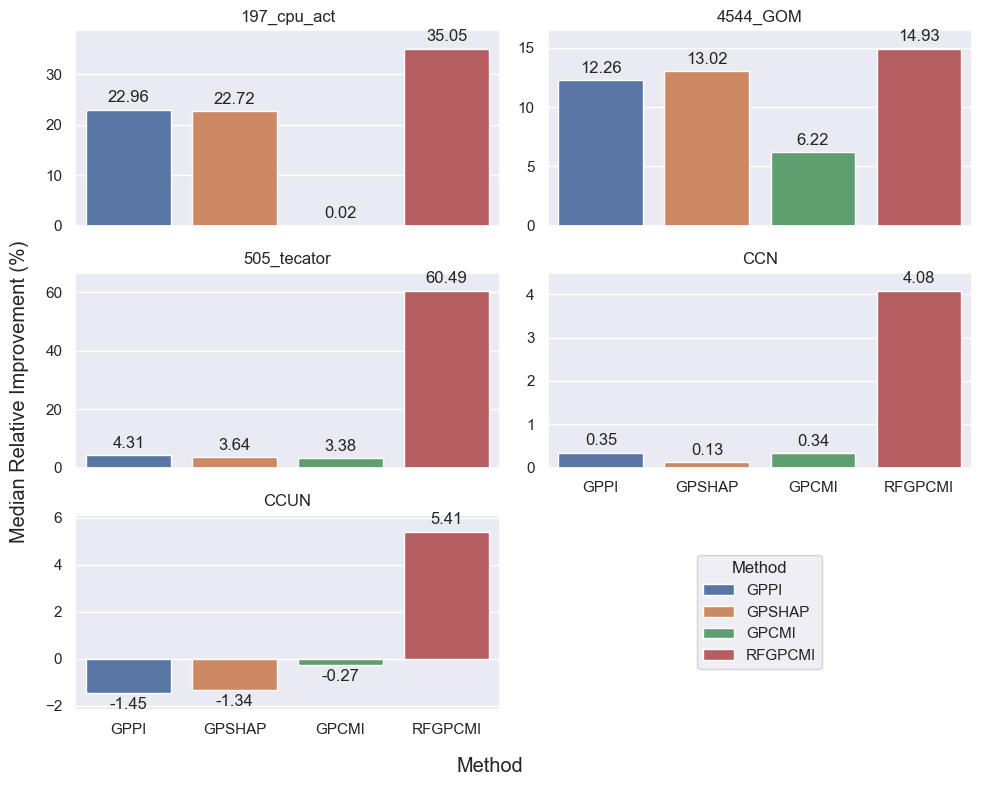

In [34]:
# Plotting relative performance of each method compared to GP for each dataset
fig, axes = plot_results(
    relative_improvement_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric", 
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Median Relative Improvement (%)", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)

plt.show()

### Model Complexity

In [35]:
# Calculate tree sizes for each run, method, and dataset in parallel using joblib
tree_sizes = {}
for ds in order['dataset']:
    tree_sizes[ds] = {}

    for m in order['method']:
        tree_sizes[ds][m] = Parallel(n_jobs=-1)(
            delayed(tree_size)(
                get_final_expr(equations[ds], m, run).simplify() 
            ) for run in tqdm(range(num_runs), desc=f"Calculating tree sizes for {ds} - {m}")  
        )

Calculating tree sizes for CCUN - GP: 100%|██████████| 100/100 [00:00<00:00, 252.18it/s]


In [36]:
# Create a DataFrame to store tree sizes with MultiIndex columns for dataset and method
tree_sizes_column_order = pd.MultiIndex.from_product([order['dataset'], order['method']], names=['dataset', 'method'])

tree_sizes_df = pd.concat(
    {ds: pd.DataFrame(tree_sizes[ds]) for ds in order['dataset']},
    axis=1,
).reindex(columns=tree_sizes_column_order)
tree_sizes_df.index.name = "run"
tree_sizes_df.tail(3)

dataset 197_cpu_act                         4544_GOM                          \
method         GPPI GPSHAP GPCMI RFGPCMI GP     GPPI GPSHAP GPCMI RFGPCMI GP   
run                                                                            
97                5     11     5      13  5        2      2     2      10  2   
98                5     11     5      15  5        6      2     6      16  6   
99                5      5     5      24  5        2      6     6      10  2   

dataset  ...  CCN                         CCUN                          
method   ... GPPI GPSHAP GPCMI RFGPCMI GP GPPI GPSHAP GPCMI RFGPCMI GP  
run      ...                                                            
97       ...    5      2     5      11  5    3      3     3      18  7  
98       ...    5      5     2      27  2    3      3     3      10  3  
99       ...    5      2     5      14  2    3      3     3       9  3  

[3 rows x 25 columns]

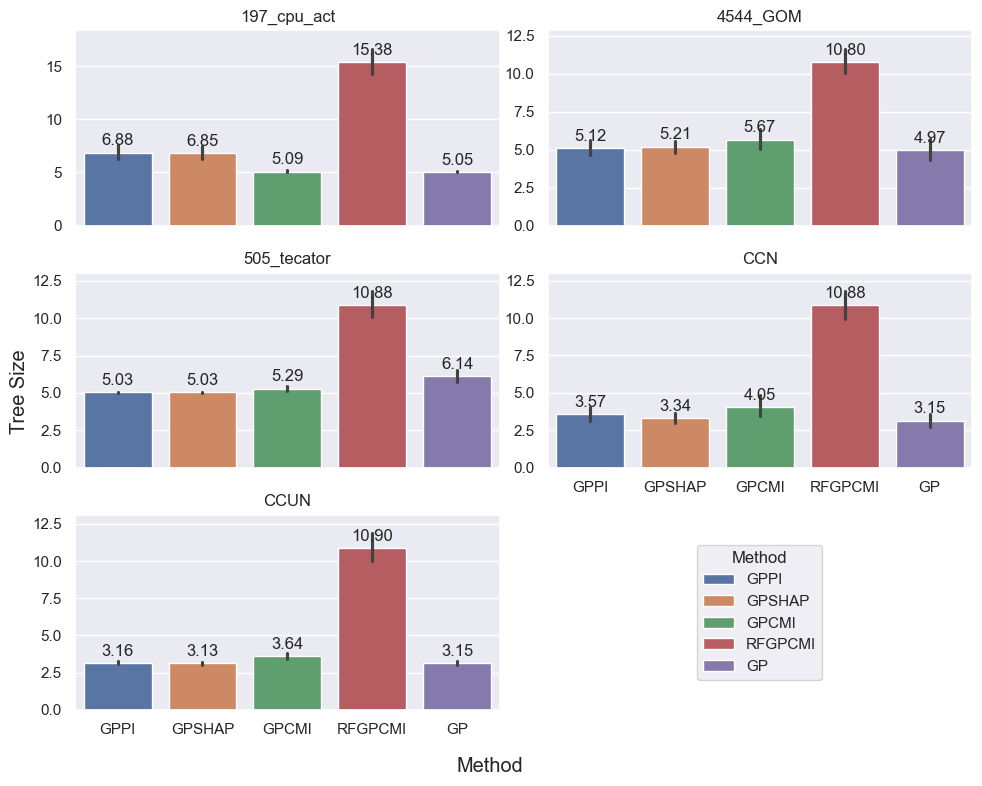

In [43]:
# Plotting tree sizes for each dataset and method at the last epoch
fig, axes = plot_results(
    tree_sizes_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level=None, 
    value_key=None,
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Tree Size", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)

plt.show()

### Feature Selection Analysis

In [89]:
# Total initial number of features for each real dataset
total_features_per_dataset = {ds: len(features[ds]['GP'][0]) for ds in features}    

# Extract the list of methods excluding "GP" for comparison
methods = results_df.columns.levels[1].to_list()
methods.remove("GP")

In [90]:
# Calculate feature retention rate (percentage) for each method and dataset
retention_rates = {}

for dataset_name in order['dataset']:
    retention_rates[dataset_name] = {}
    total_features = total_features_per_dataset[dataset_name]

    for method_name in methods:
        retention_rates[dataset_name][method_name] = np.empty(num_runs)
        features_selected = features[dataset_name][method_name]

        for run in range(num_runs): 
            if method_name == "RFGPCMI":
                selected_features = set()

                for feature_list in features_selected[run]:
                    selected_features.update(feature_list)
                    
            else:
                selected_features = set(features_selected[run])

            # Percentage of original features retained
            retention_rates[dataset_name][method_name][run] = (len(selected_features) / total_features) * 100

In [91]:
# Create a DataFrame to store retention rates with MultiIndex columns for dataset and method
retention_column_order = pd.MultiIndex.from_product(
    [order['dataset'], methods], names=['dataset', 'method']
)

retention_rate_df = pd.concat(
    {
        ds: pd.DataFrame(retention_rates[ds])
        for ds in order['dataset']
    },
    axis=1,
).reindex(columns=retention_column_order)
retention_rate_df.index.name = "run"
retention_rate_df.tail(3)

dataset 197_cpu_act                                    4544_GOM            \
method         GPPI     GPSHAP      GPCMI    RFGPCMI       GPPI    GPSHAP   
run                                                                         
97         4.761905  19.047619  52.380952  71.428571  10.256410  5.982906   
98         9.523810  19.047619  66.666667  76.190476   5.982906  5.982906   
99         4.761905  19.047619  57.142857  71.428571  11.965812  5.982906   

dataset                       505_tecator                                  \
method       GPCMI    RFGPCMI        GPPI    GPSHAP      GPCMI    RFGPCMI   
run                                                                         
97       11.965812  14.529915   16.129032  5.645161  92.741935  94.354839   
98        9.401709  11.965812   13.709677  5.645161  90.322581  91.129032   
99       10.256410   7.692308   12.096774  5.645161  93.548387  94.354839   

dataset        CCN                                      CCUN            \
method        GPPI    GPSHAP      GPCMI    RFGPCMI      GPPI    GPSHAP   
run                                                                      
97        9.016393  5.737705   2.459016   5.737705  4.838710  5.645161   
98       16.393443  5.737705   7.377049  13.114754  8.870968  5.645161   
99        6.557377  5.737705  14.754098  16.393443  6.451613  5.645161   

dataset                      
method      GPCMI   RFGPCMI  
run                          
97       5.645161  7.258065  
98       4.838710  4.838710  
99       3.225806  4.838710

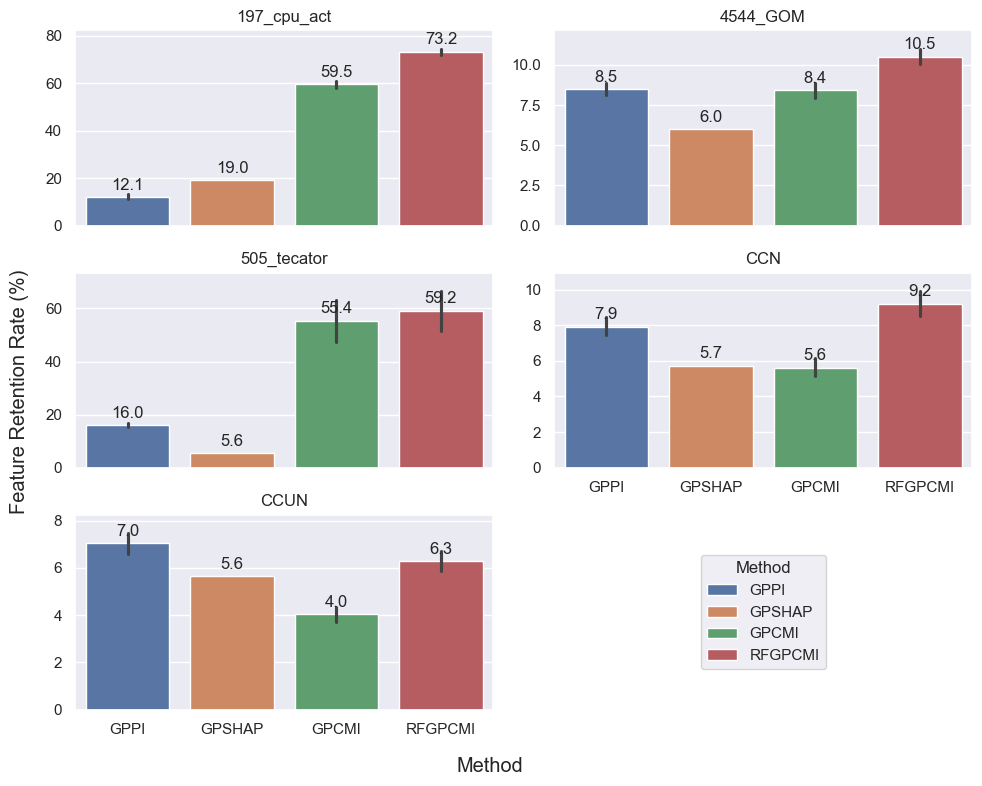

In [92]:
# Plotting feature retention rates for each dataset and method
fig, axes = plot_results(
    retention_rate_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level=None, 
    value_key=None,
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Feature Retention Rate (%)", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    # ax.axhline(y=100, color='black', linestyle='--', linewidth=1)

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.1f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)

plt.show()

### Computational Efficiency

In [ ]:
# Create a DataFrame to store execution times with MultiIndex columns for dataset and method
time_column_order = pd.MultiIndex.from_product(
    [order['dataset'], order['method']], names=['dataset', "method"]
)

execution_time_df = pd.concat({ds: pd.DataFrame(execution_times[ds]) for ds in order['dataset']},
    axis=1,
).reindex(columns=time_column_order)
execution_time_df.index.name = "run"
execution_time_df.tail(3)

dataset 197_cpu_act                                                 \
method         GPPI      GPSHAP       GPCMI     RFGPCMI         GP   
run                                                                  
97       696.455025  667.624016  141.696469  237.539906  21.988395   
98       713.579094  869.673716   99.899604  244.467918  20.565529   
99       710.341002  921.889068  185.931551  322.026756  20.785378   

dataset    4544_GOM                                               ...  \
method         GPPI      GPSHAP      GPCMI    RFGPCMI         GP  ...   
run                                                               ...   
97       566.834702  930.871812  43.002745  22.311091  15.233752  ...   
98       566.298982  904.047306  31.479435  23.438995  15.037781  ...   
99       582.755632  921.989298  27.891890  50.449294  16.217834  ...   

dataset         CCN                                                     CCUN  \
method         GPPI      GPSHAP      GPCMI    RFGPCMI         GP        GPPI   
run                                                                            
97       885.788524  669.381611  32.752383  40.939019  32.401931  673.878646   
98       855.938689  665.108441  34.350938  37.631050  34.478474  708.762464   
99       863.767125  698.723641  30.327997  37.044747  35.072514  684.121211   

dataset                                                
method        GPSHAP      GPCMI    RFGPCMI         GP  
run                                                    
97       1042.410995  46.015513  48.658387  29.752376  
98        995.093555  49.326253  48.134557  28.710149  
99        998.224033  46.770610  52.017602  29.251216  

[3 rows x 25 columns]

In [ ]:
# Calculate median relative time for each method and dataset
median_exec_time = execution_time_df.median()
baseline_exec_time = median_exec_time[:, "GP"]

relative_time = median_exec_time / baseline_exec_time
relative_time_df = relative_time.to_frame().T

relative_time_df = relative_time_df.reindex(columns=order['dataset'], level='dataset')
relative_time_df = relative_time_df.reindex(columns=order['method'], level='method')
relative_time_df

dataset 197_cpu_act                                        4544_GOM  \
method         GPPI     GPSHAP     GPCMI    RFGPCMI   GP       GPPI   
0         31.388549  41.586958  7.259355  13.878509  1.0  35.742869   

dataset                                      ...       CCN            \
method      GPSHAP     GPCMI   RFGPCMI   GP  ...      GPPI    GPSHAP   
0        52.001593  2.234341  2.644067  1.0  ...  27.14277  26.15024   

dataset                                CCUN                                 \
method      GPCMI   RFGPCMI   GP       GPPI     GPSHAP     GPCMI   RFGPCMI   
0        1.052262  1.168588  1.0  24.202721  27.878682  1.594508  1.726135   

dataset       
method    GP  
0        1.0  

[1 rows x 25 columns]

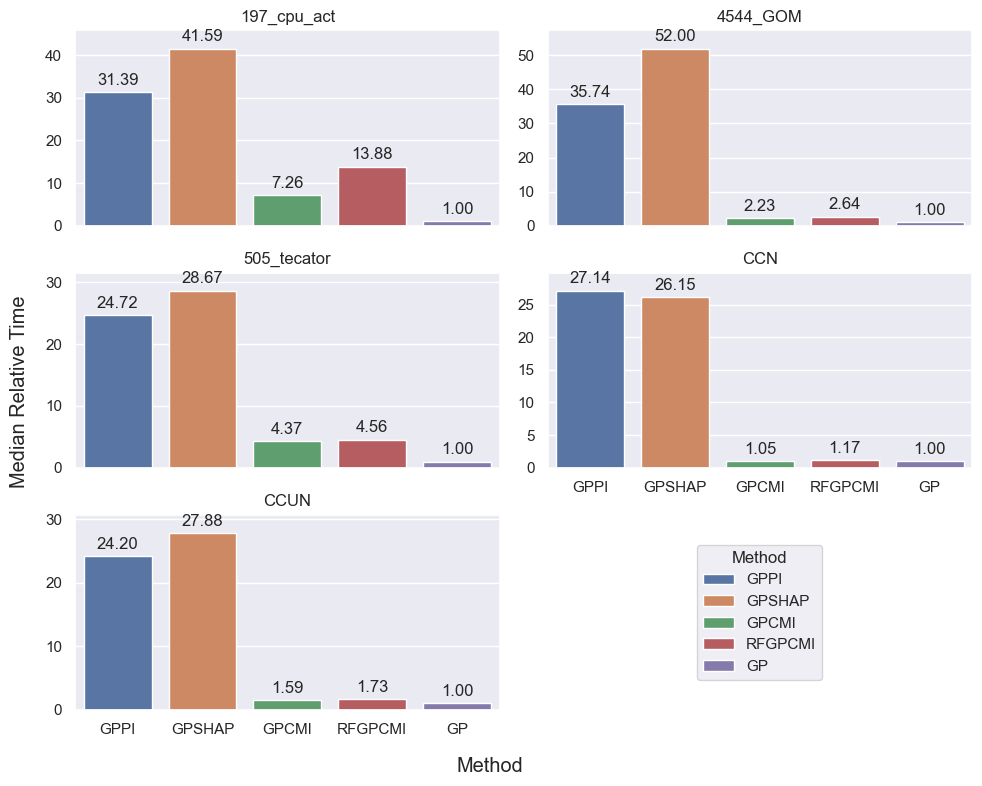

In [96]:
# Plotting relative time of each method compared to GP for each dataset
fig, axes = plot_results(
    relative_time_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level=None, 
    value_key=None,
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Median Relative Time", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)

plt.show()

In [97]:
# Calculate computational efficiency as the inverse of the product of median loss and relative time
computational_efficiency_df = 1 / (median_loss * relative_time_df)

for level, cols in order.items():
    computational_efficiency_df = computational_efficiency_df.reindex(columns=cols, level=level)

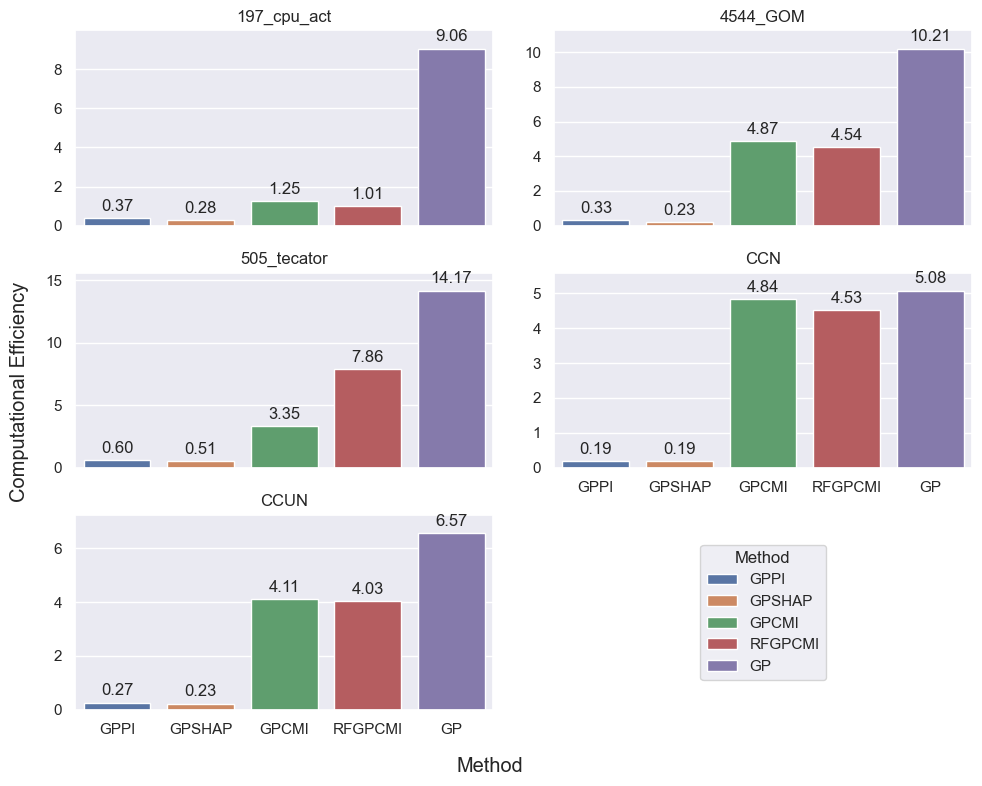

In [100]:
# Plotting the ratio of median test loss to median relative time for each dataset and method
fig, axes = plot_results(
    computational_efficiency_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric", 
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Computational Efficiency", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)

plt.show()